# Rice Type Classification

## Dataset and Imports

In [228]:
import opendatasets as ods
#ods.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

In [229]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


## Preprocessing Dataset

In [230]:
data_df = pd.read_csv('rice-type-classification/riceClassification.csv')
print(data_df.shape)
data_df.head(5)

(18185, 12)


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [231]:
data_df.dropna(inplace=True) # Drop rows with null values
data_df.drop(['id'], axis = 1, inplace=True) # Drop 'id' column
print(data_df.shape)

(18185, 11)


In [232]:
print(data_df['Class'].unique()) # check classes

[1 0]


In [233]:
print(data_df['Class'].value_counts()) # check frequency of classes

Class
1    9985
0    8200
Name: count, dtype: int64


Normalize dataset so gradients and loss do not explode - max value of each column becomes 1.

Actually, the scaling needs to be done using the maximum values from the training set only. Otherwise there is going to be a data leakage problem, and the model will not generalize to unseen data.

In [234]:
# original_df = data_df.copy()

# for column in data_df.columns:
#     data_df[column] = data_df[column] / data_df[column].abs().max() 

# data_df.head(5)

In [235]:
X = np.array(data_df.iloc[:, :-1]) # Convert all the df except the last column (the Class) into the data
y = np.array(data_df.iloc[:, -1]) # Convert the last column of the df into the labels

In [236]:
# Splitting whole dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Splitting test dataset into test and validation -> 0.7 train, 0.15 val, 0.15 test
X_test, X_val, y_test, y_val = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


Scaling the datasets using the maximum values from the training set.

In [237]:
train_max = np.max(X_train, axis=0)

X_train = X_train / train_max
X_val = X_val / train_max
X_test = X_test / train_max

### Creating Dataset Object
PyTorch is an ecosystem whose classes work together in a seamless way, therefore we need to convert the pandas dataframe into a PyTorch `Dataset` object.

We create a class which inherits from the PT `Dataset` class, overwriting its base functions.
- The data and label arrays are converted to `torch.tensor`, the PyTorch native array format, then they are sent to the device that is being used (`.to(device)`), which can either be gpu (cuda) or cpu
- We overwrite the `__len__` function to return the length of our `X` vector
- We overwrite the `__getitem__` function to return the object and its label corresponding to an index

In [238]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

We create a `dataset` object for each of our sets (training, validation, test)

In [239]:
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

### DataLoader
During the training, we go through all the data, pass it to the model, and then calculate the weights, do backpropagation etc... During this process, we do not go through the data one by one, but by *batch size*, meaning the data is divided in groups (or *batches*), and this is done by the `DataLoader` object.

Using the option `shuffle = True` lets the Dataloader shuffle the order of the data in the dataset to avoid biasing.

In [240]:
train_dataloader = DataLoader(training_data, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=8, shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=8, shuffle=True)

Since we specified `batch_size = 8`, each object of the dataloader contains 8 `X` elements and their respective labels from `y`.

In [241]:
for x,y in train_dataloader:
    print(x)
    print("=======")
    print(y)
    break

tensor([[0.9146, 0.8692, 0.9193, 0.9094, 0.8744, 0.9563, 0.7727, 0.7606, 0.8671,
         0.5364],
        [0.8774, 0.8923, 0.8604, 0.9316, 0.8416, 0.9367, 0.8173, 0.7652, 0.8217,
         0.5884],
        [0.5990, 0.8647, 0.6070, 0.9813, 0.5719, 0.7740, 0.5123, 0.6868, 0.6965,
         0.8082],
        [0.6473, 0.8406, 0.6760, 0.9641, 0.6129, 0.8046, 0.7713, 0.6863, 0.7537,
         0.7055],
        [0.6747, 0.8321, 0.7201, 0.9525, 0.6497, 0.8214, 0.7465, 0.6985, 0.7584,
         0.6556],
        [0.8267, 0.8375, 0.8659, 0.9152, 0.7852, 0.9093, 0.7292, 0.7264, 0.8593,
         0.5487],
        [0.6249, 0.8199, 0.6691, 0.9619, 0.5956, 0.7905, 0.5683, 0.6750, 0.7521,
         0.6952],
        [0.9396, 0.8927, 0.9143, 0.9176, 0.8875, 0.9693, 0.6770, 0.7681, 0.8733,
         0.5540]])
tensor([0., 0., 1., 1., 1., 0., 1., 0.])


## Building Model
Just like for the `Dataset` class, every model class inherits from the `nn.Module` PyTorch superclass.
- In the constructor, we invoke the constructor of the superclass and create the layers
    - A `nn.Linear` layer corresponds to one layer of a normal mlp
    - We create one hidden layer, also `nn.Linear`
    - The output has 1 output feature because it is simply one number, the probability that the object belongs to class 1
    - We use `nn.Sigmoid` as the activation function, to obtain the class from the probability
- In the `forward` method, we specify how the data flows inside the model: `input_layer -> hidden_layer -> sigmoid -> output`

In [242]:
HIDDEN_NEURONS = 10

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__() 

        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.hidden_layer = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layer(x)
        x = self.sigmoid(x)
        return x
    
model = MyModel().to(device)

### Model Summary
The `summary` function takes as input the model and the number of input features. Then it performs one forward pass to check the output shape and the number of parameters in every layer.

`-1`  is the batch size, which in this instance is 1.

In [243]:
summary(model, (X.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 10]                  110
├─Linear: 1-2                            [-1, 1]                   11
├─Sigmoid: 1-3                           [-1, 1]                   --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 10]                  110
├─Linear: 1-2                            [-1, 1]                   11
├─Sigmoid: 1-3                           [-1, 1]                   --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### Loss and Optimizer
The optimizer must be told which parameters it is working on.

In [244]:
criterion = nn.BCELoss() # loss function
optimizer = Adam(model.parameters(), lr=1e-3)

## Training Model
- create the loss and accuracy lists for the training and validation sets
- do a loop on the number of epochs
- start with the **training**
    - the totals are calculated by summing the values for each batch, and we record each value in our lists
    - for each epoch, we run through all the batches: 
        - we make predictions - remember to apply `.squeeze(1)` to the results, in order to eliminate the extra dimension and make this array the same dimension of `labels`, otherwise PyTorch cannot calculate the loss
        - calculate the batch loss and add the batch loss to the total loss
        - calculate the batch accuracy and add the batch accuracy to the total accuracy
        - do backpropagation to calculate the gradients
        - apply `optimizer.step()` to change the weights according to the gradients
        - apply `optimizer.zero_grad()` to zero the gradients again in preparation for the next batch
- then do **validation**
    - validation means that after the training we get the predictions of the model on a separated dataset in order to test it. On this dataset we **don't do** backpropagation
    - remember run the pass on the validation dataset within `with torch.no_grad():`, which will ensure gradients and weights are not modified. This is PyTorch's standard inference mode
    - the totals are calculated by summing the values for each batch, and we record each value in our lists
    - for each epoch, we run through all the batches:
        - we make predictions - remember to apply `.squeeze(1)` to the results
        - calculate the batch loss and add the batch loss to the total loss
        - calculate the batch accuracy and add the batch accuracy to the total accuracy
- append the total values to their lists
    - divide the accuracy for the number of items in the training set, and convert to percentage by multiplying by 100
    - since the loss will be large, divide it by 1000

*Note*: when we calculate the predictions as `prediction = model(inputs)`, the result is a tensor that contains not only the predicted labels, but also the `grad` objects for each layer of the model. These objects are then passed to the loss object when the loss is calculated with `loss = criterion(prediction, labels)`, and used during the backward pass, when `loss.backward()` is called.

In [245]:
total_loss_train_list = []
total_loss_validation_list = []
total_acc_train_list = []
total_acc_validation_list = []

epochs = 10

for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_validation = 0
    total_loss_validation = 0

    for data in train_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)
        
        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        batch_acc = (prediction.round() == labels).sum().item()

        total_acc_train += batch_acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_validation += batch_loss.item()

            batch_acc = (prediction.round() == labels).sum().item()

            total_acc_validation += batch_acc

    total_loss_train_list.append(round(total_loss_train/1000, 4))
    total_acc_train_list.append(round(total_acc_train/training_data.__len__() * 100, 4))

    total_loss_validation_list.append(round(total_loss_validation/1000, 4))
    total_acc_validation_list.append(round(total_acc_validation/validation_data.__len__() * 100, 4))

    print(f'''Epoch: {epoch+1} | Train Loss: {round(total_loss_train/1000, 4)} | Train Acc: {round(total_acc_train/training_data.__len__() * 100, 4)} | Val Loss: {round(total_loss_validation/1000, 4)} | Val Acc: {round(total_acc_validation/validation_data.__len__() * 100, 4)}''')



Epoch: 1 | Train Loss: 0.5817 | Train Acc: 94.4458 | Val Loss: 0.0401 | Val Acc: 98.607
Epoch: 2 | Train Loss: 0.1275 | Train Acc: 98.4838 | Val Loss: 0.0197 | Val Acc: 98.6437
Epoch: 3 | Train Loss: 0.0844 | Train Acc: 98.4916 | Val Loss: 0.0166 | Val Acc: 98.5704
Epoch: 4 | Train Loss: 0.0739 | Train Acc: 98.5781 | Val Loss: 0.0153 | Val Acc: 98.607
Epoch: 5 | Train Loss: 0.0709 | Train Acc: 98.5309 | Val Loss: 0.0153 | Val Acc: 98.5704
Epoch: 6 | Train Loss: 0.0702 | Train Acc: 98.5152 | Val Loss: 0.015 | Val Acc: 98.607
Epoch: 7 | Train Loss: 0.0687 | Train Acc: 98.5073 | Val Loss: 0.0149 | Val Acc: 98.607
Epoch: 8 | Train Loss: 0.0697 | Train Acc: 98.5781 | Val Loss: 0.0153 | Val Acc: 98.5337
Epoch: 9 | Train Loss: 0.0689 | Train Acc: 98.5309 | Val Loss: 0.0151 | Val Acc: 98.5337
Epoch: 10 | Train Loss: 0.0685 | Train Acc: 98.5781 | Val Loss: 0.0164 | Val Acc: 98.2771


## Testing Model
In this stage we test how well the model performs on unseen data, by making predictions on the test dataset

In [246]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in testing_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_test += batch_loss.item()

        batch_acc = (prediction.round() == labels).sum().item()

        total_acc_test += batch_acc

print(f"Test Acc: {round(total_acc_test/testing_data.__len__() * 100, 4)}")
        

Test Acc: 99.0836


## Visualization

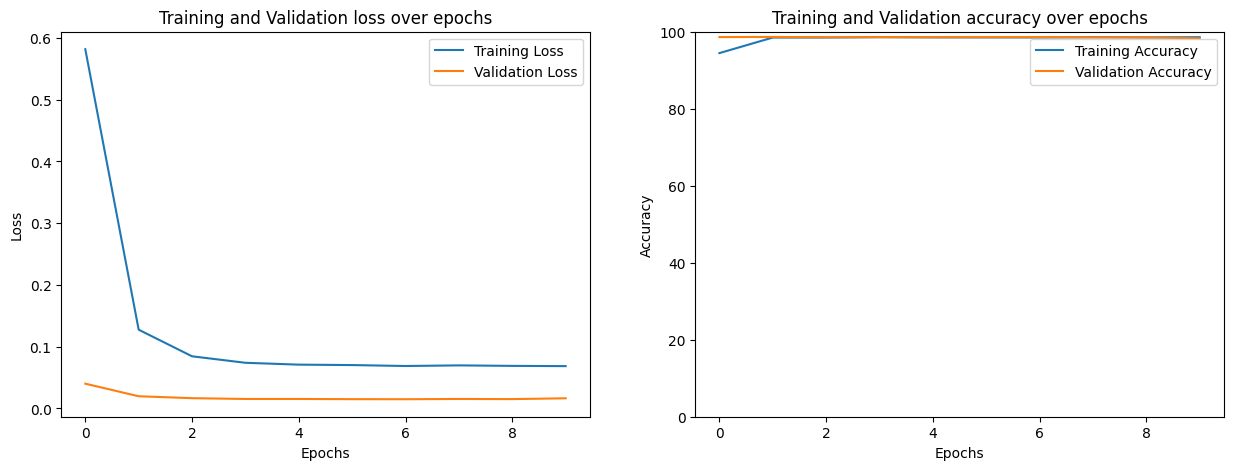

In [250]:
fig, axs = plt.subplots(nrows = 1, ncols=2, figsize=(15,5))

axs[0].plot(total_loss_train_list, label = 'Training Loss')
axs[0].plot(total_loss_validation_list, label = 'Validation Loss')
axs[0].set_title("Training and Validation loss over epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
#axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_acc_train_list, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_list, label = 'Validation Accuracy')
axs[1].set_title("Training and Validation accuracy over epochs")
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0,100])
axs[1].legend()

plt.show()

## Single Prediction
After training the model, we can use it to make predictions on a single piece of data. In order to do that, the data has to first be normalized using the same scaler used for the training set.

In [257]:
area = 5284 / train_max[0]
MajorAxisLength = 81 / train_max[1]
MinorAxisLength = 42 / train_max[2]
Eccentricity = 0.66 / train_max[3]
ConvexArea = 4213 / train_max[4]
EquivDiameter = 65 / train_max[5]
Extent = 0.73 / train_max[6]
Perimeter = 220 / train_max[7]
Roundness = 0.83 / train_max[8]
AspectRation = 1.5 / train_max[9]

new_data = torch.tensor([
    area,
    MajorAxisLength,
    MinorAxisLength,
    Eccentricity,
    ConvexArea,
    EquivDiameter,
    Extent,
    Perimeter,
    Roundness,
    AspectRation
], dtype=torch.float32).to(device)

In [260]:
pred = model(new_data)
print(round(pred.item()))

0
